In [ ]:
import DistanceBased.similarities as S

# Seputar Dataset

#### Inisiasi Dataset menggunakan object MatrixRating

In [1]:
from MatrixRating import MatrixRating as m

data = m("data/ml-100k")

#### Deskripsi dataset

In [8]:
import numpy as np

transform = np.array(data.transformationData(data.dataset)).tolist()

print("Jumlah rating pada dataset =", data.checkNumberOfRating(transform))
print("Jumlah item =", data.numberOfItem)
print("Jumlah user =", data.numberOfUser)
print("Id Item tertinggi =", data.maxIdOfItem)
print("Id User tertinggi =", data.maxIdOfUser)

Jumlah rating pada dataset = 100000
Jumlah item = 1682
Jumlah user = 943
Id Item tertinggi = 1682
Id User tertinggi = 943


#### Deskripsi data training setiap fold

In [4]:
import pandas as pd

training = data.train
test = data.test

for index,matrix in zip(range(1,6),training) :
    df = pd.read_csv(f"data/ml-100k/u{index}.base",sep="\t", names=["user_id","item_id","rating","timestamp"])

    if index == 1 :
        print("_____________________________________________________")

    print(f"Train k-{index}")
    print("_____________________________________________________")
    print("Max Unique Id user =", max(pd.unique(df["user_id"])))
    print("Max Unique Id item = ", max(pd.unique(df["item_id"])))
    print("number of user = ", len(pd.unique(df["user_id"])))
    print("number of item = ", len(pd.unique(df["item_id"])))
    print(f"number rating = ", data.checkNumberOfRating(matrix))
    print("_____________________________________________________")


_____________________________________________________
Train k-1
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1650
number rating =  80000
_____________________________________________________
Train k-2
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1648
number rating =  80000
_____________________________________________________
Train k-3
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1650
number rating =  80000
_____________________________________________________
Train k-4
_____________________________________________________
Max Unique Id user = 943
Max Unique Id item =  1682
number of user =  943
number of item =  1660
number rating =  80000
________________________________________________

#### Deskripsi data test setiap fold

In [5]:
for index,matrix in zip(range(1,6),test) :
    df = pd.read_csv(f"data/ml-100k/u{index}.test",sep="\t", names=["user_id","item_id","rating","timestamp"])

    if index == 1 :
        print("_____________________________________________")
    print(f"Test k-{index}")
    print("_____________________________________________")
    print("Unik Id tertinggi user =", max(pd.unique(df["user_id"])))
    print("Unik Id tertinggi item = ", max(pd.unique(df["item_id"])))
    print("Jumlah user = ", len(pd.unique(df["user_id"])))
    print("Jumlah item = ", len(pd.unique(df["item_id"])))
    print(f"Jumlah rating = ", data.checkNumberOfRating(matrix))
    print("_____________________________________________")

_____________________________________________
Test k-1
_____________________________________________
Unik Id tertinggi user = 462
Unik Id tertinggi item =  1591
Jumlah user =  459
Jumlah item =  1410
Jumlah rating =  20000
_____________________________________________
Test k-2
_____________________________________________
Unik Id tertinggi user = 658
Unik Id tertinggi item =  1624
Jumlah user =  653
Jumlah item =  1420
Jumlah rating =  20000
_____________________________________________
Test k-3
_____________________________________________
Unik Id tertinggi user = 877
Unik Id tertinggi item =  1669
Jumlah user =  869
Jumlah item =  1423
Jumlah rating =  20000
_____________________________________________
Test k-4
_____________________________________________
Unik Id tertinggi user = 943
Unik Id tertinggi item =  1679
Jumlah user =  923
Jumlah item =  1394
Jumlah rating =  20000
_____________________________________________
Test k-5
_____________________________________________
Unik Id

# Tversky Index

## User-based

$$

TI_{user} = \frac{| I_A \cap I_B |}{|I_A \cap I_B| + \alpha_1 |I_A - I_B| + \alpha_2 |I_A - I_B|}

$$

In [1]:
import DistanceBased.similarities as S

ti_user = S.TI("data/ml-100k",k=5,opsional="user-based",alpha_1=0.7,alpha_2=0.3)

### Similarity

#### Fold-1

In [2]:
ti_user.show_similarity(indexFold=0)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.056338,0.029155,0.020263,0.172414,0.258824,0.202020,0.048309,0.020387,0.179299,...,0.252215,0.065913,0.182349,0.093897,0.141844,0.064103,0.197472,0.069238,0.118443,0.241546
1,0.087591,1.000000,0.082418,0.062112,0.018083,0.213115,0.087051,0.027027,0.094937,0.088968,...,0.087282,0.277078,0.325779,0.375000,0.298013,0.187354,0.199667,0.144509,0.135397,0.089286
2,0.049917,0.094937,1.000000,0.126050,0.021322,0.114068,0.023952,0.104895,0.000000,0.062762,...,0.041783,0.031949,0.144695,0.126582,0.096154,0.058309,0.174081,0.076336,0.092379,0.014286
3,0.039761,0.091743,0.164835,1.000000,0.026954,0.000000,0.040706,0.106383,0.000000,0.026316,...,0.016129,0.046512,0.114504,0.137615,0.094787,0.040816,0.119332,0.182927,0.149254,0.033223
4,0.201536,0.013210,0.013870,0.014728,1.000000,0.165460,0.227273,0.082531,0.029718,0.097933,...,0.293356,0.053050,0.084666,0.026420,0.124870,0.051020,0.177453,0.056899,0.137300,0.289220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.093583,0.172786,0.046838,0.025974,0.064935,0.118871,0.081466,0.023095,0.000000,0.032000,...,0.080925,0.391304,0.299090,0.215983,0.434783,1.000000,0.075301,0.146699,0.051724,0.141677
939,0.216638,0.138090,0.108043,0.063211,0.166341,0.278035,0.273775,0.071514,0.038217,0.271581,...,0.354052,0.080831,0.221277,0.149597,0.167754,0.055804,1.000000,0.085890,0.233266,0.223464
940,0.125224,0.182482,0.084034,0.153061,0.093677,0.103306,0.025221,0.163934,0.105263,0.022936,...,0.044379,0.221402,0.275862,0.255474,0.292887,0.199336,0.147368,1.000000,0.102302,0.075988
941,0.146138,0.104012,0.062794,0.084034,0.145278,0.192525,0.167785,0.046656,0.033956,0.143713,...,0.251163,0.059701,0.122574,0.089153,0.114025,0.042857,0.263158,0.064620,1.000000,0.179754


#### Fold-2

In [3]:
ti_user.show_similarity(indexFold=1)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.048514,0.018293,0.025316,0.244919,0.281266,0.354235,0.120192,0.031766,0.215164,...,0.292969,0.060864,0.194672,0.091130,0.156757,0.065750,0.221982,0.037688,0.119115,0.344828
1,0.085016,1.000000,0.099751,0.117302,0.014706,0.226064,0.073952,0.070588,0.089552,0.112202,...,0.160692,0.272277,0.308555,0.319410,0.261866,0.207373,0.213816,0.084986,0.171756,0.088496
2,0.032609,0.102828,1.000000,0.156250,0.000000,0.041040,0.050167,0.049505,0.031847,0.043353,...,0.000000,0.026110,0.173410,0.077720,0.101695,0.024213,0.153322,0.060241,0.119284,0.012987
3,0.051282,0.160643,0.208333,1.000000,0.000000,0.067682,0.066288,0.227273,0.057471,0.018116,...,0.030864,0.000000,0.108696,0.162602,0.088889,0.000000,0.156600,0.104167,0.110193,0.047619
4,0.299173,0.009615,0.000000,0.000000,1.000000,0.130246,0.292366,0.123223,0.010363,0.134028,...,0.257123,0.038685,0.081906,0.028930,0.120870,0.046992,0.145396,0.040692,0.077990,0.309641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.110331,0.193133,0.021882,0.000000,0.067935,0.148515,0.094266,0.083160,0.025575,0.065020,...,0.080925,0.391304,0.299090,0.215983,0.434783,1.000000,0.075301,0.146699,0.051724,0.141677
939,0.292231,0.149083,0.104287,0.087173,0.157618,0.313015,0.309708,0.169109,0.062735,0.323404,...,0.354052,0.080831,0.221277,0.149597,0.167754,0.055804,1.000000,0.085890,0.233266,0.223464
940,0.074257,0.108303,0.074627,0.096154,0.073126,0.161551,0.046125,0.205479,0.099010,0.103448,...,0.044379,0.221402,0.275862,0.255474,0.292887,0.199336,0.147368,1.000000,0.102302,0.075988
941,0.173985,0.133136,0.089955,0.065898,0.095137,0.294695,0.249494,0.115774,0.049917,0.183861,...,0.251163,0.059701,0.122574,0.089153,0.114025,0.042857,0.263158,0.064620,1.000000,0.179754


#### Fold-3

In [4]:
ti_user.show_similarity(indexFold=2)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.055960,0.033860,0.029464,0.287081,0.317826,0.428089,0.128707,0.017741,0.248943,...,0.311194,0.080092,0.199319,0.097087,0.158568,0.073116,0.235656,0.058928,0.123126,0.351288
1,0.094073,1.000000,0.158416,0.139535,0.048603,0.188053,0.078797,0.096154,0.117925,0.104408,...,0.135440,0.145530,0.316456,0.309917,0.261628,0.117417,0.189781,0.139535,0.166389,0.046083
2,0.058366,0.164948,1.000000,0.278481,0.012690,0.069045,0.102866,0.123711,0.051414,0.072551,...,0.035253,0.044843,0.172185,0.111359,0.137825,0.021008,0.200000,0.101266,0.159011,0.024010
3,0.058617,0.193548,0.372881,1.000000,0.032626,0.072046,0.084317,0.225806,0.093458,0.046012,...,0.044379,0.036900,0.120690,0.218978,0.146444,0.033223,0.210526,0.181818,0.204604,0.045593
4,0.338983,0.032600,0.008251,0.017590,1.000000,0.180012,0.366144,0.146699,0.026525,0.191205,...,0.326428,0.042088,0.080160,0.041982,0.129032,0.041051,0.179598,0.052770,0.122324,0.330159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.124760,0.120240,0.020661,0.024450,0.062344,0.124575,0.109091,0.080160,0.024814,0.071344,...,0.080925,0.391304,0.299090,0.215983,0.434783,1.000000,0.075301,0.146699,0.051724,0.141677
939,0.317680,0.143646,0.146067,0.122699,0.206954,0.356866,0.348119,0.176796,0.074166,0.368885,...,0.354052,0.080831,0.221277,0.149597,0.167754,0.055804,1.000000,0.085890,0.233266,0.223464
940,0.117233,0.193548,0.135593,0.181818,0.097879,0.100865,0.059022,0.193548,0.140187,0.076687,...,0.044379,0.221402,0.275862,0.255474,0.292887,0.199336,0.147368,1.000000,0.102302,0.075988
941,0.183706,0.141044,0.129683,0.129241,0.158103,0.338518,0.283912,0.155148,0.065253,0.209324,...,0.251163,0.059701,0.122574,0.089153,0.114025,0.042857,0.263158,0.064620,1.000000,0.179754


#### Fold-4

In [5]:
ti_user.show_similarity(indexFold=3)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.088174,0.041819,0.038525,0.316540,0.360169,0.431276,0.156576,0.011007,0.283061,...,0.223597,0.049207,0.150267,0.065182,0.135610,0.059267,0.148338,0.022198,0.079031,0.250000
1,0.147569,1.000000,0.126126,0.130719,0.056497,0.299401,0.107095,0.107527,0.108932,0.166113,...,0.120968,0.191083,0.297872,0.248447,0.284360,0.200803,0.184255,0.135135,0.111111,0.065617
2,0.071620,0.130841,1.000000,0.283019,0.000000,0.093071,0.082248,0.114723,0.047170,0.092166,...,0.042313,0.045872,0.179104,0.089286,0.117057,0.000000,0.124555,0.048900,0.118812,0.013755
3,0.078387,0.192926,0.405405,1.000000,0.031949,0.080754,0.080972,0.200669,0.050000,0.062112,...,0.020619,0.047170,0.089686,0.178571,0.133690,0.000000,0.236686,0.108108,0.177936,0.019881
4,0.376259,0.038314,0.000000,0.016750,1.000000,0.230282,0.399282,0.154679,0.025126,0.177045,...,0.209601,0.016584,0.069444,0.041051,0.116959,0.032441,0.142643,0.033927,0.078431,0.293921
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.111789,0.248756,0.000000,0.000000,0.055788,0.131894,0.075415,0.025641,0.034364,0.081633,...,0.052083,0.297030,0.186220,0.126984,0.408602,1.000000,0.069930,0.108696,0.026882,0.117845
939,0.238683,0.173776,0.113269,0.153257,0.200422,0.338028,0.256904,0.177134,0.076628,0.320911,...,0.223048,0.037453,0.130208,0.146520,0.143678,0.053476,1.000000,0.039448,0.132670,0.133333
940,0.046620,0.217391,0.076628,0.121212,0.067682,0.098870,0.033333,0.113636,0.121212,0.065681,...,0.044444,0.169492,0.194647,0.211640,0.176991,0.147059,0.066007,1.000000,0.040650,0.042735
941,0.138632,0.120000,0.123711,0.128535,0.122699,0.214592,0.168539,0.163934,0.000000,0.168067,...,0.133531,0.049875,0.094488,0.048426,0.088810,0.023364,0.151803,0.026738,1.000000,0.101156


#### Fold-5

In [6]:
ti_user.show_similarity(indexFold=4)

,0,1,2,3,4,5,6,7,8,9,...,933,934,935,936,937,938,939,940,941,942
0,1.000000,0.077680,0.041885,0.038398,0.311665,0.357295,0.438385,0.161290,0.022014,0.292683,...,0.134436,0.033296,0.074587,0.022309,0.032485,0.022161,0.095745,0.033746,0.053967,0.126449
1,0.129422,1.000000,0.143113,0.127119,0.055866,0.250000,0.090556,0.105079,0.107296,0.143805,...,0.102916,0.110865,0.171103,0.135747,0.080645,0.022026,0.113422,0.023419,0.099602,0.073126
2,0.072072,0.150659,1.000000,0.307329,0.011820,0.094637,0.086840,0.114943,0.023981,0.081871,...,0.000000,0.000000,0.062893,0.050891,0.067114,0.049383,0.145833,0.052910,0.066225,0.020080
3,0.077178,0.182927,0.423453,1.000000,0.015552,0.066845,0.077280,0.156740,0.093458,0.061350,...,0.060423,0.000000,0.036496,0.052632,0.040984,0.049505,0.036101,0.057143,0.120000,0.101695
4,0.369588,0.038023,0.007728,0.008285,1.000000,0.219020,0.390180,0.145482,0.024979,0.189140,...,0.166920,0.025295,0.031721,0.000000,0.024370,0.025231,0.063291,0.008606,0.048504,0.070203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,0.046243,0.034965,0.075472,0.056180,0.049917,0.028329,0.023962,0.108303,0.000000,0.000000,...,0.034602,0.127389,0.086207,0.000000,0.049505,1.000000,0.000000,0.150376,0.000000,0.000000
939,0.173077,0.130152,0.159091,0.028329,0.103093,0.192963,0.154170,0.154867,0.028818,0.152866,...,0.086207,0.000000,0.098280,0.061920,0.106101,0.000000,1.000000,0.064935,0.104439,0.093458
940,0.074813,0.044843,0.099010,0.086957,0.018587,0.062208,0.025231,0.140187,0.000000,0.036563,...,0.000000,0.000000,0.059172,0.000000,0.071942,0.206186,0.116279,1.000000,0.068966,0.157895
941,0.102354,0.125628,0.079576,0.103448,0.084151,0.207824,0.124633,0.077121,0.140845,0.096953,...,0.099751,0.000000,0.058140,0.000000,0.031847,0.000000,0.115274,0.040816,1.000000,0.082192


### Prediction

#### Fold-1

In [9]:
ti_user.show_prediction(indexFold=0)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.000000,3.000000,3.118046,4.000000,1.000000,5.000000,3.778814,...,2.534423,3.544426,3.222151,2.222151,3.469500,1.559986,3.559986,2.559986,3.700818,3.315551
1,4.000000,3.471105,2.226973,3.234343,3.911505,4.802027,3.764921,4.439970,3.981135,2.000000,...,2.652941,3.662944,3.340670,2.340670,3.588018,1.678505,3.678505,2.678505,3.819337,3.434069
2,3.809849,1.911387,1.754591,2.426402,2.955009,2.381925,3.689795,3.082187,3.782218,3.281548,...,1.852941,2.862944,2.540670,1.540670,2.788018,0.878505,2.878505,1.878505,3.019337,2.634069
3,5.174843,3.086228,3.932868,3.827915,3.875928,4.395409,4.958539,4.673947,4.882553,4.816666,...,3.210084,4.220087,3.897813,2.897813,4.145161,2.235648,4.235648,3.235648,4.376480,3.991212
4,3.616252,2.735395,2.489203,2.688137,2.823267,2.625705,3.765675,3.723274,2.171125,3.177718,...,1.808985,2.818988,2.496714,1.496714,2.744062,0.000000,0.000000,0.000000,2.975381,2.590113
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,5.031178,4.218958,3.181480,3.703407,4.298817,4.977308,4.515306,4.994958,5.000000,4.501167,...,3.118247,4.128250,3.805976,2.805976,4.053325,2.143811,4.143811,3.143811,4.284643,3.899376
939,2.832099,3.221254,3.434966,2.000000,3.201555,3.251031,4.000000,5.000000,3.000000,3.819536,...,2.310885,3.320888,2.998614,1.998614,3.245962,1.336449,3.336449,2.336449,3.477281,3.092013
940,5.000000,3.542448,3.927601,2.954376,3.222685,4.120397,4.000000,4.971798,4.433632,3.832122,...,2.898396,3.908399,3.586124,2.586124,3.833473,1.923959,3.923959,2.923959,4.064792,3.679524
941,4.938179,4.417697,3.576573,4.316882,4.172894,4.193138,4.637819,5.302279,4.988895,4.363102,...,3.118764,4.128767,3.806493,2.806493,4.053841,2.144327,4.144327,3.144327,4.285160,3.899892


#### Fold-2

In [10]:
ti_user.show_prediction(indexFold=1)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,4.375243,3.747939,4.000000,3.000000,3.000000,5.000000,4.000000,4.370673,4.704283,3.000000,...,2.485969,3.495972,3.173697,2.173697,3.421046,1.511532,3.511532,2.511532,3.652365,3.267097
1,4.324259,2.492191,2.818968,3.728655,3.729990,4.392274,4.188229,3.995908,4.412282,3.585605,...,2.657819,3.667822,3.345548,2.345548,3.592896,1.683383,3.683383,2.683383,3.824215,3.438947
2,3.064085,2.274090,2.036918,2.063833,2.709067,1.868666,3.033674,2.908377,2.488389,2.680213,...,1.484520,2.494523,2.172249,1.172249,2.419597,0.510084,2.510084,1.510084,2.650916,2.265648
3,4.872377,3.997077,4.004497,3.383240,4.885446,4.748683,4.731512,3.547276,4.926102,4.891539,...,3.241830,4.251833,3.929559,2.929559,4.176907,2.267394,4.267394,3.267394,4.408226,4.022958
4,4.000000,3.000000,1.325324,2.239608,2.974951,2.203589,3.373090,2.405702,2.599591,2.488598,...,1.700269,2.710272,2.387998,1.387998,2.635347,0.725833,2.725833,1.725833,2.866665,2.481398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.594650,4.358750,4.760783,3.762623,4.316665,4.883468,4.408313,4.003406,5.000000,4.142176,...,3.118247,4.128250,3.805976,2.805976,4.053325,2.143811,4.143811,3.143811,4.284643,3.899376
939,3.578602,3.428515,2.803484,2.000000,3.454379,3.197435,4.000000,5.000000,3.000000,4.001316,...,2.310885,3.320888,2.998614,1.998614,3.245962,1.336449,3.336449,2.336449,3.477281,3.092013
940,5.000000,3.620249,4.024659,3.129628,4.298006,4.123172,4.000000,4.547586,4.151231,4.455918,...,2.898396,3.908399,3.586124,2.586124,3.833473,1.923959,3.923959,2.923959,4.064792,3.679524
941,5.045310,3.650979,3.794962,4.362607,3.719249,4.059325,4.605737,4.775041,4.653453,4.853598,...,3.118764,4.128767,3.806493,2.806493,4.053841,2.144327,4.144327,3.144327,4.285160,3.899892


#### Fold-3

In [11]:
ti_user.show_prediction(indexFold=2)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,3.000000,3.501228,5.000000,4.000000,1.000000,5.000000,3.000000,...,2.458828,3.467763,3.150237,2.150237,3.360107,1.468311,3.468311,2.468311,3.594444,3.209177
1,4.000000,2.874610,2.754656,2.737877,3.591434,4.051485,3.625398,3.933398,4.009191,2.000000,...,2.479875,3.488809,3.171283,2.171283,3.381154,1.489358,3.489358,2.489358,3.615491,3.230223
2,3.370727,2.384014,2.651079,3.108356,2.243777,2.491618,2.964428,2.999208,2.998672,2.693702,...,1.756061,2.764996,2.447470,1.447470,2.657340,0.765544,2.765544,1.765544,2.891677,2.506410
3,4.888867,3.777313,3.823231,4.001089,4.275166,4.594135,4.851513,5.219550,4.337739,4.007816,...,3.201903,4.210837,3.893311,2.893311,4.103182,2.211386,4.211386,3.211386,4.337519,3.952251
4,4.000000,3.000000,1.709499,3.252568,2.403628,2.522013,4.474877,3.216164,3.855404,3.637787,...,1.746466,2.755400,2.437875,1.437875,2.647745,0.755949,2.755949,1.755949,2.882082,2.496814
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.166376,4.720963,3.670123,3.403420,4.900518,4.964918,3.555041,4.357921,5.000000,4.221589,...,3.149027,4.157961,3.840436,2.840436,4.050306,2.158510,4.158510,3.158510,4.284643,3.899376
939,3.338273,2.886578,2.432271,2.000000,3.200975,3.790155,4.000000,5.000000,3.000000,4.184781,...,2.341665,3.350599,3.033073,2.033073,3.242944,1.351148,3.351148,2.351148,3.477281,3.092013
940,5.000000,3.710326,3.269672,3.903112,3.299740,3.842476,4.000000,5.082568,4.359684,3.785139,...,2.929175,3.938110,3.620584,2.620584,3.830455,1.938658,3.938658,2.938658,4.064792,3.679524
941,4.340034,3.595143,3.814931,4.239618,3.847928,4.359267,4.947344,4.873095,4.606407,4.940375,...,3.149544,4.158478,3.840952,2.840952,4.050823,2.159027,4.159027,3.159027,4.285160,3.899892


#### Fold-4

In [12]:
ti_user.show_prediction(indexFold=3)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,4.000000,4.284764,3.000000,5.000000,4.290297,1.000000,5.000000,3.000000,...,0,3.394070,3.016964,2.016964,0,0,0,2.557610,3.592634,3.259710
1,4.000000,3.857485,2.423132,3.921553,3.407773,3.835378,3.787116,4.401343,3.493294,2.000000,...,0,3.515758,3.138653,2.138653,0,0,0,2.679298,3.714323,3.381399
2,3.904547,1.676708,2.186498,2.631331,2.826858,2.656220,2.687816,3.959409,3.103443,2.843179,...,0,2.584922,2.207816,1.207816,0,0,0,1.748462,2.783486,2.450562
3,4.653445,3.578790,4.275738,3.866899,4.233795,3.430709,4.083246,4.826002,4.589035,3.804444,...,0,4.146460,3.769355,2.769355,0,0,0,3.310000,4.345025,4.012100
4,4.000000,3.000000,1.948822,3.509996,2.510344,3.274538,4.201322,2.985441,4.237178,3.482251,...,0,2.660658,2.283552,1.283552,0,0,0,1.824198,2.859222,2.526298
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.379961,4.617677,3.684070,4.292432,4.558956,4.933104,3.892533,4.739135,5.000000,4.256632,...,0,4.220703,3.843597,2.843597,0,0,0,0.000000,4.419267,4.086343
939,3.732577,2.730070,2.839462,2.895349,2.600920,2.963712,4.000000,4.181978,3.947460,4.228953,...,0,3.281309,2.904203,1.904203,0,0,0,2.444848,3.479873,3.146949
940,5.000000,3.540254,4.022952,3.545782,3.582473,4.248824,4.157749,4.689033,4.506606,3.337323,...,0,0.000000,3.286022,2.286022,0,0,0,2.826667,3.861692,3.528767
941,4.548539,4.057574,3.218100,4.897322,3.724001,4.100986,4.494870,4.640791,5.023401,4.939400,...,0,4.115609,3.738504,2.738504,0,0,0,3.279149,4.314174,3.981249


#### Fold-5

In [13]:
ti_user.show_prediction(indexFold=4)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,5.000000,3.000000,2.973749,3.000000,3.000000,5.000000,4.000000,1.000000,5.000000,3.000000,...,2.288519,0,0,0,3.295885,1.384495,3.384495,0,0,0
1,4.000000,2.752988,2.665508,3.847126,3.293424,3.991530,3.455381,4.386050,4.622531,2.000000,...,2.363323,0,0,0,3.370690,1.459299,3.459299,0,0,0
2,3.177106,1.925667,2.139358,2.651364,2.376248,2.923669,2.781101,3.277798,3.268711,2.623911,...,1.436007,0,0,0,2.443374,0.531983,2.531983,0,0,0
3,4.164820,3.526531,3.984896,4.362042,4.165120,4.827926,3.953863,3.843934,4.253636,3.895268,...,2.963636,0,0,0,3.971003,2.059613,4.059613,0,0,0
4,4.000000,3.000000,2.617464,2.956277,1.984101,3.008998,4.021838,3.458893,4.314793,3.057112,...,1.562075,0,0,0,2.569442,0.000000,0.000000,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
938,4.312576,3.683581,3.639599,3.451382,4.202931,4.050963,3.895360,5.004566,3.295320,4.324306,...,0.000000,0,0,0,3.635776,1.724385,3.724385,0,0,0
939,3.629358,2.743849,2.481879,2.000000,3.352068,3.264891,3.035333,5.000000,3.000000,3.367121,...,2.105543,0,0,0,3.112910,1.201519,3.201519,0,0,0
940,4.999887,3.994912,3.823895,4.016675,3.828190,5.074804,4.000000,4.590558,4.447972,4.792729,...,0.000000,0,0,0,4.126847,2.215457,4.215457,0,0,0
941,4.931313,3.617070,2.980732,4.388710,3.829741,4.292661,4.061787,4.679303,4.176600,4.484399,...,2.878409,0,0,0,3.885776,1.974385,3.974385,0,0,0


## Item-based

$$

TI_{item} = \frac{| U_A \cap U_B |}{|U_A \cap U_B| + \alpha_1 |U_A - U_B| + \alpha_2 |U_A - U_B|}

$$

In [1]:
import DistanceBased.similarities as S

ti_item = S.TI("data/ml-100k",k=5,opsional="item-based",alpha_1=0.7,alpha_2=0.3)

100%|██████████| 5/5 [03:15<00:00, 39.08s/it]


### Similarity

#### Fold-1

In [2]:
ti_item.show_similarity(indexFold=0)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.000000,0.246996,0.206469,0.331872,0.131579,0.032835,0.563576,0.343750,0.427025,0.151724,...,0.003726,0.0,0.000000,0.000000,0.003726,0.0,0.0,0.0,0.003726,0.003726
1,0.392781,1.000000,0.229167,0.512821,0.276008,0.062893,0.392512,0.318979,0.224033,0.125786,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.013550,0.013550
2,0.358423,0.261905,1.000000,0.327553,0.163934,0.068376,0.338866,0.268199,0.332542,0.201613,...,0.000000,0.0,0.000000,0.000000,0.018939,0.0,0.0,0.0,0.000000,0.018939
3,0.451833,0.423280,0.239100,1.000000,0.249288,0.063644,0.462701,0.425408,0.372093,0.162429,...,0.000000,0.0,0.008333,0.008333,0.008333,0.0,0.0,0.0,0.008333,0.008333
4,0.232843,0.325815,0.169492,0.351406,1.000000,0.018416,0.327635,0.219561,0.229320,0.056980,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.020576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1680,0.008651,0.031056,0.000000,0.019231,0.000000,0.000000,0.010776,0.019011,0.013423,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,0.000000


#### Fold-2

In [3]:
ti_item.show_similarity(indexFold=1)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.000000,0.261762,0.174010,0.314361,0.140533,0.038880,0.546243,0.346420,0.421150,0.143277,...,0.003986,0.0,0.000000,0.000000,0.003986,0.0,0.0,0.0,0.003986,0.003986
1,0.405924,1.000000,0.222458,0.466403,0.253432,0.061350,0.393423,0.376766,0.274064,0.155440,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.013298,0.013298
2,0.307390,0.270619,1.000000,0.308960,0.168453,0.095969,0.298084,0.224490,0.241265,0.134128,...,0.000000,0.0,0.000000,0.000000,0.021834,0.0,0.0,0.0,0.000000,0.021834
3,0.417032,0.386885,0.214439,1.000000,0.249643,0.055118,0.477294,0.404858,0.374167,0.190141,...,0.000000,0.0,0.008285,0.008285,0.008285,0.0,0.0,0.0,0.008285,0.008285
4,0.247396,0.306513,0.167428,0.357873,1.000000,0.037879,0.310734,0.233029,0.239868,0.073746,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.021505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1680,0.009251,0.030488,0.000000,0.019120,0.000000,0.000000,0.010406,0.018797,0.013263,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,0.000000


#### Fold-3

In [4]:
ti_item.show_similarity(indexFold=2)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.000000,0.229885,0.201342,0.327533,0.139360,0.035672,0.525539,0.347361,0.413146,0.131530,...,0.0,0.0,0.000000,0.000000,0.004065,0.0,0.0,0.0,0.004065,0.004065
1,0.352423,1.000000,0.212551,0.460792,0.218522,0.072376,0.389841,0.353846,0.246502,0.165460,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.013055,0.013055
2,0.342205,0.246479,1.000000,0.330330,0.152144,0.067682,0.343643,0.197740,0.261283,0.164609,...,0.0,0.0,0.000000,0.000000,0.018939,0.0,0.0,0.0,0.000000,0.018939
3,0.444650,0.397767,0.247934,1.000000,0.230061,0.051195,0.466601,0.419963,0.374187,0.190840,...,0.0,0.0,0.009017,0.009017,0.009017,0.0,0.0,0.0,0.009017,0.009017
4,0.244224,0.266160,0.160116,0.320513,1.000000,0.018939,0.316092,0.260260,0.225000,0.045045,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.021505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,1.0,1.0,1.0,0.000000,0.000000
1680,0.009434,0.029940,0.000000,0.020790,0.000000,0.000000,0.010672,0.018382,0.013423,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,1.000000,0.000000


#### Fold-4

In [5]:
ti_item.show_similarity(indexFold=3)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.000000,0.240283,0.193219,0.324289,0.135036,0.034789,0.530412,0.324934,0.393483,0.152616,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000
1,0.379888,1.000000,0.216685,0.432612,0.260870,0.013038,0.357793,0.301003,0.272156,0.160944,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.014085,0.000000
2,0.333963,0.247831,1.000000,0.300300,0.237099,0.106383,0.373444,0.251762,0.292683,0.178326,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.019724
3,0.437891,0.356653,0.218818,1.000000,0.241228,0.032922,0.429185,0.419708,0.377459,0.181159,...,0.0,0.0,0.008636,0.008636,0.0,0.0,0.0,0.0,0.008636,0.000000
4,0.234177,0.300000,0.238429,0.332661,1.000000,0.017953,0.305768,0.324544,0.302535,0.083102,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.020000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,1.0,0.0,0.0,0.000000,0.000000
1678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,1.0,0.0,0.000000,0.000000
1679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,1.0,0.000000,0.000000
1680,0.000000,0.032258,0.000000,0.019920,0.000000,0.000000,0.010537,0.000000,0.013643,0.000000,...,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,1.000000,0.000000


#### Fold-5

In [6]:
ti_item.show_similarity(indexFold=4)

,0,1,2,3,4,5,6,7,8,9,...,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681
0,1.000000,0.232891,0.188609,0.327212,0.151796,0.039293,0.531668,0.345054,0.406530,0.156192,...,0.004019,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
1,0.365374,1.000000,0.257235,0.498366,0.268817,0.051680,0.353082,0.330189,0.266075,0.152505,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.323604,0.293758,1.000000,0.381978,0.233838,0.070053,0.367847,0.243218,0.208696,0.167832,...,0.000000,0.0,0.0,0.0,0.019455,0.0,0.0,0.0,0.0,0.0
3,0.434590,0.407754,0.276792,1.000000,0.270270,0.040000,0.461109,0.446224,0.355385,0.164993,...,0.000000,0.0,0.0,0.0,0.008382,0.0,0.0,0.0,0.0,0.0
4,0.261313,0.308642,0.235131,0.374753,1.000000,0.035461,0.328542,0.207156,0.262467,0.056497,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1677,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,1.0,1.0,0.0,0.0,0.0
1678,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,1.0,1.0,0.0,0.0,0.0
1679,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.0,0.0
1680,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,1.0,0.0


# Dice Coefficient

In [1]:
import DistanceBased.similarities as S
from hybrid import HCF

hybrid = HCF("data/ml-100k",object=S.TI,k_user=20,k_item=30,gamma=0.7,toyData=False,N=20,n=20,alpha_1=0.1,alpha_2=0.1)

 # Evaluasi

### Skenario 1 : Mencari $\alpha_1$ dan $\alpha_2$ terbaik

In [2]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0.7],
            "k_user" : [20],
            "k_item" : [30],
            "alpha_1" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
            "alpha_2" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
        }

skenario_pertama = EksperimenHCF("data/ml-100k",object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/FBO_A1_and_A2_v2.joblib",N=20,n=20)

In [3]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])


mean_dcg_alpha = []
mean_dcg_alpha_fold = []
mean_ndcg_alpha = []
mean_ndcg_alpha_fold = []

for alpha_1_index in skenario_pertama.result_skenario[0.7][20][30] :

    skenario_pertama_alpha_1 = skenario_pertama.result_skenario[0.7][20][30][alpha_1_index]
    for alpha_2_index in skenario_pertama_alpha_1 :
        mean_dcg_alpha_per_fold = []
        mean_ndcg_alpha_per_fold = []

        for i in range(len(skenario_pertama_alpha_1[0])) :
            mean_dcg_alpha_per_fold += [sum(skenario_pertama_alpha_1[alpha_2_index][i])/len(skenario_pertama_alpha_1[alpha_2_index][i])]
            mean_ndcg_alpha_per_fold += [sum(np.array(skenario_pertama_alpha_1[alpha_2_index][i])/idcg[n-1])/len(skenario_pertama_alpha_1[alpha_2_index][i])]
        
        mean_dcg_alpha_per_fold += [sum(mean_dcg_alpha_per_fold)/len(skenario_pertama_alpha_1)]
        mean_ndcg_alpha_per_fold += [sum(mean_ndcg_alpha_per_fold)/len(skenario_pertama_alpha_1)]

        mean_dcg_alpha_fold += [mean_dcg_alpha_per_fold]
        mean_ndcg_alpha_fold += [mean_ndcg_alpha_per_fold]
        mean_dcg_alpha += [[alpha_1_index,alpha_2_index,sum(mean_dcg_alpha_per_fold)/len(skenario_pertama_alpha_1)]]
        mean_ndcg_alpha += [[alpha_1_index,alpha_2_index,sum(mean_ndcg_alpha_per_fold)/len(skenario_pertama_alpha_1)]]

#### DCG@20 $\alpha_1$ dan $\alpha_2$ per *fold*

In [4]:
import pandas as pd
import itertools
alpha = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(mean_dcg_alpha_fold,index=[ f"A1_{str(i)}_A2_{str(j)}" for i,j in itertools.product(alpha,alpha)],columns=[f"Fold-{i}" if i != 6 else "Rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,Rata-rata
A1_0.0_A2_0.0,1.483601,1.381528,0.890230,0.711363,0.827350,0.481279
A1_0.0_A2_0.1,1.357035,0.667028,0.430665,0.515717,0.280681,0.295557
A1_0.0_A2_0.2,1.338256,0.649562,0.408540,0.507570,0.267324,0.288296
A1_0.0_A2_0.3,1.354280,0.638753,0.410196,0.501866,0.238743,0.285803
A1_0.0_A2_0.4,1.296982,0.638384,0.411812,0.517298,0.239691,0.282197
...,...,...,...,...,...,...
A1_1.0_A2_0.6,3.587243,1.715307,1.317091,1.427168,0.690276,0.794280
A1_1.0_A2_0.7,3.525385,1.728623,1.256647,1.456203,0.655000,0.783805
A1_1.0_A2_0.8,3.365592,1.705574,1.248892,1.361203,0.674986,0.759659
A1_1.0_A2_0.9,3.299401,1.717581,1.210623,1.351560,0.660649,0.749074


#### NDCG@20 $\alpha_1$ dan $\alpha_2$ per fold

In [5]:
import pandas as pd
import itertools
alpha = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(mean_ndcg_alpha_fold,index=[ f"A1_{str(i)}_A2_{str(j)}" for i,j in itertools.product(alpha,alpha)],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.0_A2_0.0,0.016559,0.015420,0.009936,0.007940,0.009234,0.005372
A1_0.0_A2_0.1,0.015146,0.007445,0.004807,0.005756,0.003133,0.003299
A1_0.0_A2_0.2,0.014937,0.007250,0.004560,0.005665,0.002984,0.003218
A1_0.0_A2_0.3,0.015116,0.007129,0.004578,0.005601,0.002665,0.003190
A1_0.0_A2_0.4,0.014476,0.007125,0.004596,0.005774,0.002675,0.003150
...,...,...,...,...,...,...
A1_1.0_A2_0.6,0.040038,0.019145,0.014700,0.015929,0.007704,0.008865
A1_1.0_A2_0.7,0.039348,0.019294,0.014026,0.016253,0.007311,0.008748
A1_1.0_A2_0.8,0.037564,0.019036,0.013939,0.015193,0.007534,0.008479
A1_1.0_A2_0.9,0.036826,0.019170,0.013512,0.015085,0.007374,0.008361


#### DCG $\alpha_1$ dan $\alpha_2$ Plot

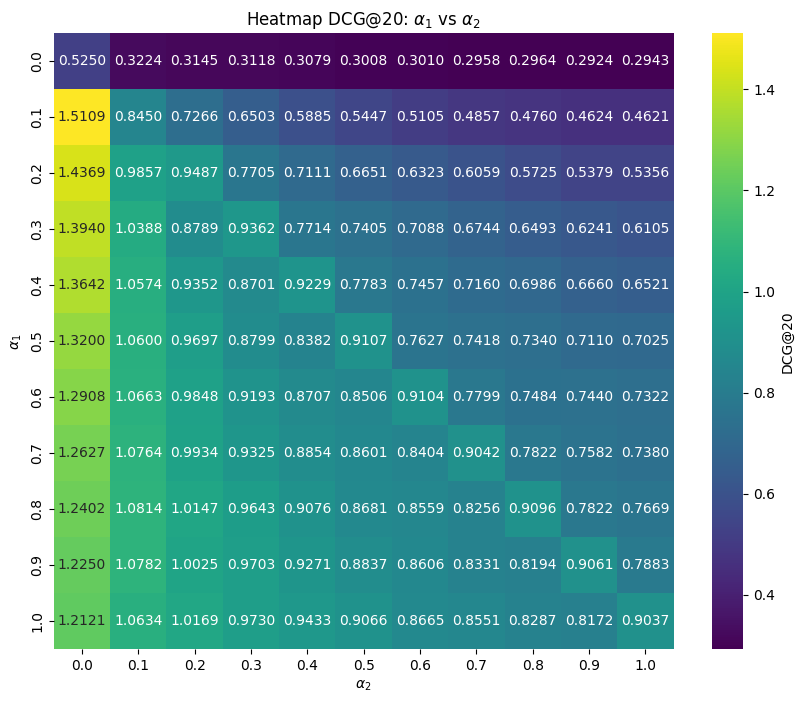

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create DataFrame from mean_dcg
df = pd.DataFrame(mean_dcg_alpha, columns=["alpha_1", "alpha_2", "DCG"])

# Pivot the DataFrame to get alpha_1 as rows and alpha_2 as columns
heatmap_data = df.pivot(index="alpha_1", columns="alpha_2", values="DCG")

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="viridis", cbar_kws={'label': 'DCG@20'})
plt.xlabel(r'$\alpha_2$')
plt.ylabel(r'$\alpha_1$')
plt.title(r'Heatmap DCG@20: $\alpha_1$ vs $\alpha_2$')
plt.show()


#### NDCG $\alpha_1$ dan $\alpha_2$ Plot

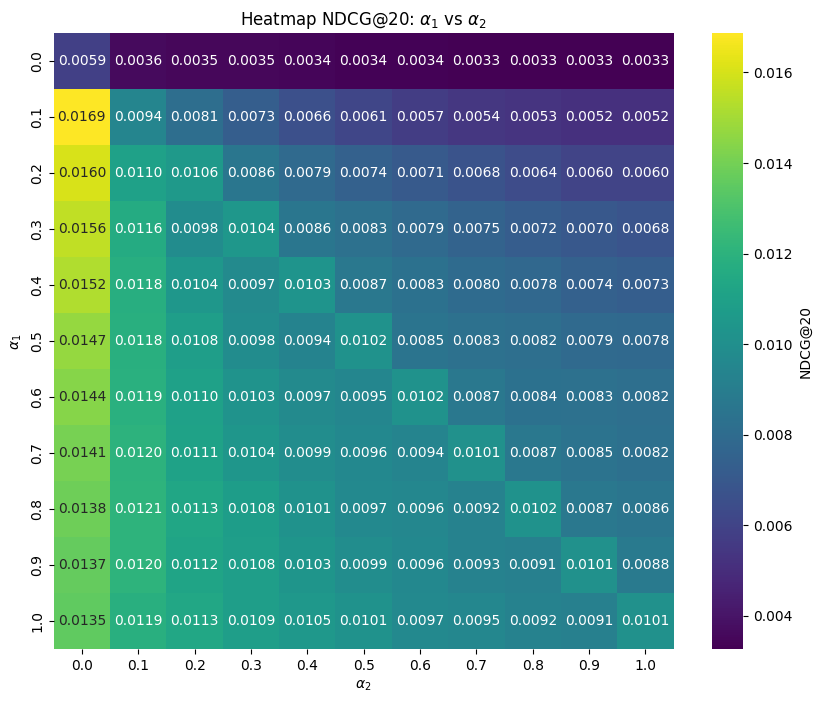

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Create DataFrame from mean_ndcg
df = pd.DataFrame(mean_ndcg_alpha, columns=["alpha_1", "alpha_2", "NDCG"])

# Pivot the DataFrame to get alpha_1 as rows and alpha_2 as columns
heatmap_data = df.pivot(index="alpha_1", columns="alpha_2", values="NDCG")

plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="viridis", cbar_kws={'label': 'NDCG@20'})
plt.xlabel(r'$\alpha_2$')
plt.ylabel(r'$\alpha_1$')
plt.title(r'Heatmap NDCG@20: $\alpha_1$ vs $\alpha_2$')
plt.show()


### Skenario 2 : Mencari $k^{user}$ terbaik

In [24]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0.7],
            "k_user" : [5,10,15,18,20,25,30,40,50,100,200],
            "k_item" : [30],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

skenario_kedua = EksperimenHCF("data/ml-100k",object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/FBO_K_user.joblib",N=20,n=20)

In [25]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])
k_user = [5,10,15,18,20,25,30,40,50,100,200]


mean_dcg_k_user_fold = []
mean_ndcg_k_user_fold = []
mean_dcg_k_user = []
mean_ndcg_k_user = []

for k_user_index in k_user :

    skenario_kedua_k_user = skenario_kedua.result_skenario[0.7][k_user_index][30][0.1][0]
    mean_dcg_k_user_per_fold = []
    mean_ndcg_k_user_per_fold = []

    for i in range(len(skenario_kedua_k_user)) :
        mean_dcg_k_user_per_fold += [sum(skenario_kedua_k_user[i])/len(skenario_kedua_k_user[i])]
        mean_ndcg_k_user_per_fold += [sum(np.array(skenario_kedua_k_user[i])/idcg[n-1])/len(skenario_kedua_k_user[i])]
    
    mean_dcg_k_user_per_fold += [sum(mean_dcg_k_user_per_fold)/len(skenario_kedua_k_user)]
    mean_ndcg_k_user_per_fold += [sum(mean_ndcg_k_user_per_fold)/len(skenario_kedua_k_user)]

    mean_dcg_k_user_fold += [mean_dcg_k_user_per_fold]
    mean_ndcg_k_user_fold += [mean_ndcg_k_user_per_fold]
    mean_dcg_k_user += [[k_user_index,30,sum(mean_dcg_k_user_per_fold)/len(skenario_kedua_k_user)]]
    mean_ndcg_k_user += [[k_user_index,30,sum(mean_ndcg_k_user_per_fold)/len(skenario_kedua_k_user)]]

#### DCG $k^{user}$ per fold 

In [26]:
import pandas as pd

k_user = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(mean_dcg_k_user_fold,index=[ f"A1_{str(0.1)}_A2_{str(0)}_N_{i}" for i in k_user],columns=[f"Fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,Fold-1,Fold-2,Fold-3,Fold-4,Fold-5,rata-rata
A1_0.1_A2_0_N_5,6.120393,3.402389,3.680902,3.101523,2.501807,3.761403
A1_0.1_A2_0_N_10,6.473667,3.049781,2.972159,2.903736,2.034128,3.486694
A1_0.1_A2_0_N_15,6.384138,2.965078,2.748774,2.703529,1.712103,3.302724
A1_0.1_A2_0_N_18,6.020117,2.972633,2.569505,2.563572,1.635921,3.152350
A1_0.1_A2_0_N_20,6.014967,2.714146,2.553658,2.470527,1.481215,3.046903
A1_0.1_A2_0_N_25,5.621949,2.429720,2.271514,2.273340,1.321668,2.783638
A1_0.1_A2_0_N_30,5.386251,2.338132,1.930890,1.993669,1.129013,2.555591
A1_0.1_A2_0_N_40,5.031219,2.298457,1.618864,1.802431,0.869656,2.324125
A1_0.1_A2_0_N_50,4.451435,1.969877,1.382566,1.690813,0.706774,2.040293
A1_0.1_A2_0_N_100,3.038008,1.143685,0.644841,1.015593,0.374698,1.243365


#### $k^{user}$ per fold

In [27]:
import pandas as pd
k_user = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(mean_ndcg_k_user_fold,index=[ f"A1_{str(0.1)}_A2_{str(0)}_N_{i}" for i in k_user],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
A1_0.1_A2_0_N_5,0.068312,0.037975,0.041084,0.034617,0.027923,0.041982
A1_0.1_A2_0_N_10,0.072255,0.034040,0.033173,0.032409,0.022704,0.038916
A1_0.1_A2_0_N_15,0.071255,0.033094,0.030680,0.030175,0.019109,0.036863
A1_0.1_A2_0_N_18,0.067192,0.033178,0.028679,0.028613,0.018259,0.035184
A1_0.1_A2_0_N_20,0.067135,0.030293,0.028502,0.027574,0.016532,0.034007
A1_0.1_A2_0_N_25,0.062748,0.027119,0.025353,0.025373,0.014752,0.031069
A1_0.1_A2_0_N_30,0.060118,0.026097,0.021551,0.022252,0.012601,0.028524
A1_0.1_A2_0_N_40,0.056155,0.025654,0.018069,0.020117,0.009706,0.025940
A1_0.1_A2_0_N_50,0.049684,0.021986,0.015431,0.018872,0.007889,0.022772
A1_0.1_A2_0_N_100,0.033908,0.012765,0.007197,0.011335,0.004182,0.013878


#### DCG $k^{user}$ Plot

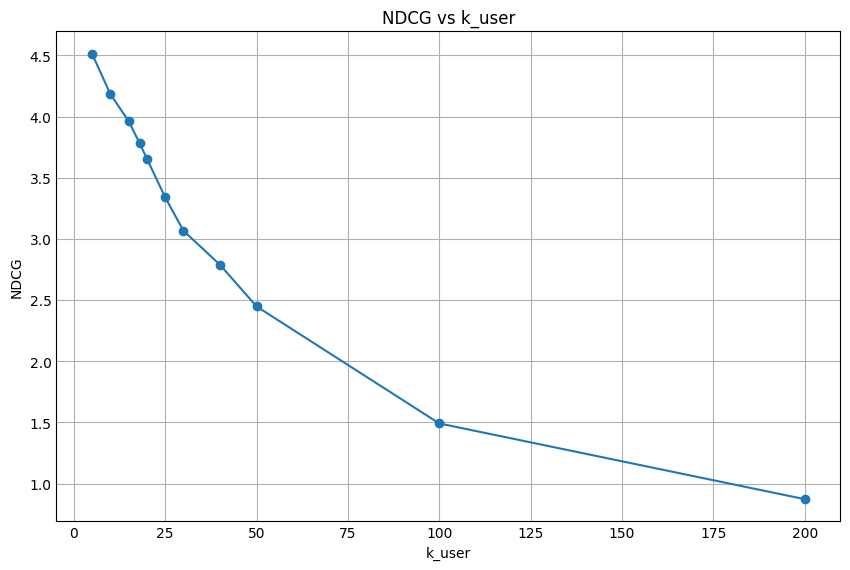

In [31]:
import pandas as pd

df = pd.DataFrame(mean_dcg_k_user, index=[i for i in range(1, len(mean_dcg_k_user) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["NDCG"], marker='o')
plt.xlabel("k_user")
plt.ylabel("NDCG")
plt.title("NDCG vs k_user")
plt.grid(True)
plt.show()

#### NDCG $k^{user}$ Plot

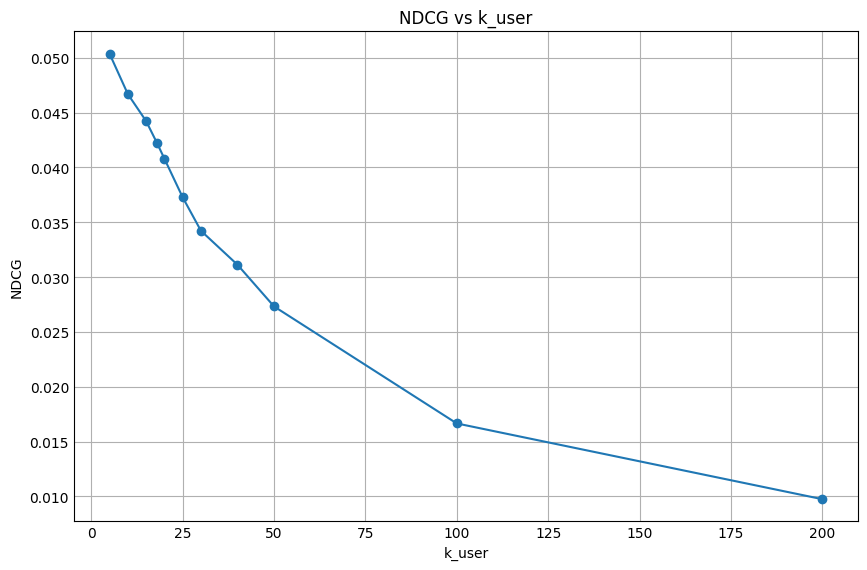

In [29]:
import pandas as pd

df = pd.DataFrame(mean_ndcg_k_user, index=[i for i in range(1, len(mean_ndcg_k_user) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.style.use("_mpl-gallery")

plt.figure(figsize=(8, 5))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["NDCG"], marker='o')
plt.xlabel("k_user")
plt.ylabel("NDCG")
plt.title("NDCG vs k_user")
plt.grid(True)
plt.show()

### Skenario 3 : Mencari $k^{item}$ terbaik

In [10]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0.7],
            "k_user" : [5],
            "k_item" : [5,10,15,18,20,25,30,40,50,100,200],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

skenario_kedua = EksperimenHCF("data/ml-100k",object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/FBO_K_item.joblib",N=20,n=20)

In [11]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])
k_item = [5,10,15,18,20,25,30,40,50,100,200]


mean_dcg_k_item_fold = []
mean_ndcg_k_item_fold = []
mean_dcg_k_item = []
mean_ndcg_k_item = []

for k_item_index in k_item :

    skenario_kedua_k_user = skenario_kedua.result_skenario[0.7][5][k_item_index][0.1][0]
    mean_dcg_per_fold = []
    mean_ndcg_per_fold = []

    for i in range(len(skenario_kedua_k_user)) :
        mean_dcg_per_fold += [sum(skenario_kedua_k_user[i])/len(skenario_kedua_k_user[i])]
        mean_ndcg_per_fold += [sum(np.array(skenario_kedua_k_user[i])/idcg[n-1])/len(skenario_kedua_k_user[i])]
    
    mean_dcg_per_fold += [sum(mean_dcg_per_fold)/len(skenario_kedua_k_user)]
    mean_ndcg_per_fold += [sum(mean_ndcg_per_fold)/len(skenario_kedua_k_user)]

    mean_dcg_k_item_fold += [mean_dcg_per_fold]
    mean_ndcg_k_item_fold += [mean_ndcg_per_fold]
    mean_dcg_k_item += [[k_item_index,30,sum(mean_dcg_per_fold)/len(skenario_kedua_k_user)]]
    mean_ndcg_k_item += [[k_item_index,30,sum(mean_ndcg_per_fold)/len(skenario_kedua_k_user)]]

#### DCG@20 $k^{item}$

In [12]:
import pandas as pd

k_item = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(mean_dcg_k_item_fold,index=[ f"k_item_{str(i)}" for i in k_item],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
k_item_5,5.762116,3.349590,3.597269,3.027099,2.624333,3.672082
k_item_10,5.909406,3.427288,3.645916,3.078745,2.625614,3.737394
k_item_15,5.886557,3.400323,3.767459,3.057702,2.488213,3.720051
k_item_18,6.079989,3.297579,3.692861,3.120375,2.554758,3.749113
k_item_20,6.295430,3.338731,3.627808,3.058509,2.527179,3.769531
k_item_25,6.026037,3.379786,3.652568,3.082798,2.516514,3.731541
k_item_30,6.120393,3.402389,3.680902,3.101523,2.501807,3.761403
k_item_40,6.233013,3.275216,3.602992,3.091093,2.466407,3.733744
k_item_50,6.148571,3.289699,3.682423,3.059335,2.438766,3.723759
k_item_100,6.258673,3.372383,3.633104,3.062922,2.492764,3.763969


#### NDCG@20 $k^{item}$ 

In [13]:
import pandas as pd

k_item = [5,10,15,18,20,25,30,40,50,100,200]

pd.DataFrame(mean_ndcg_k_item_fold,index=[ f"k_item_{str(i)}" for i in k_item],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
k_item_5,0.064313,0.037386,0.040150,0.033786,0.029291,0.040985
k_item_10,0.065957,0.038253,0.040693,0.034363,0.029305,0.041714
k_item_15,0.065702,0.037952,0.042050,0.034128,0.027772,0.041521
k_item_18,0.067861,0.036805,0.041217,0.034827,0.028514,0.041845
k_item_20,0.070265,0.037265,0.040491,0.034137,0.028207,0.042073
k_item_25,0.067258,0.037723,0.040767,0.034408,0.028088,0.041649
k_item_30,0.068312,0.037975,0.041084,0.034617,0.027923,0.041982
k_item_40,0.069569,0.036556,0.040214,0.034501,0.027528,0.041673
k_item_50,0.068626,0.036717,0.041101,0.034146,0.027220,0.041562
k_item_100,0.069855,0.037640,0.040550,0.034186,0.027822,0.042011


#### DCG@20 $k^{item}$ plot 

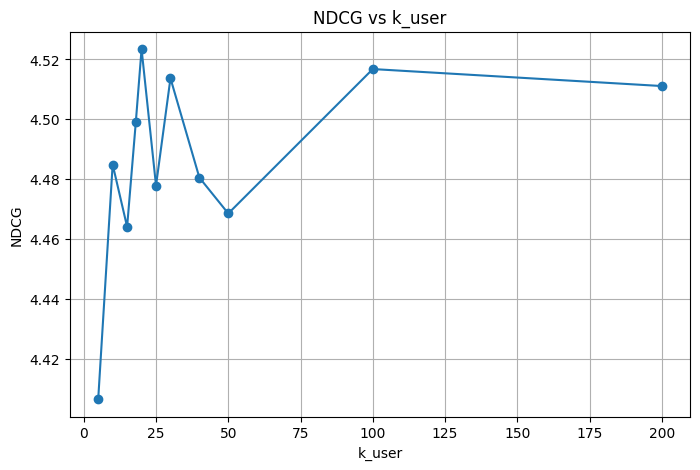

In [14]:
import pandas as pd

df = pd.DataFrame(mean_dcg_k_item, index=[i for i in range(1, len(mean_dcg_k_item) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["NDCG"], marker='o')
plt.xlabel("k_user")
plt.ylabel("NDCG")
plt.title("NDCG vs k_user")
plt.grid(True)
plt.show()

#### NDCG@20 $k^{item}$ plot

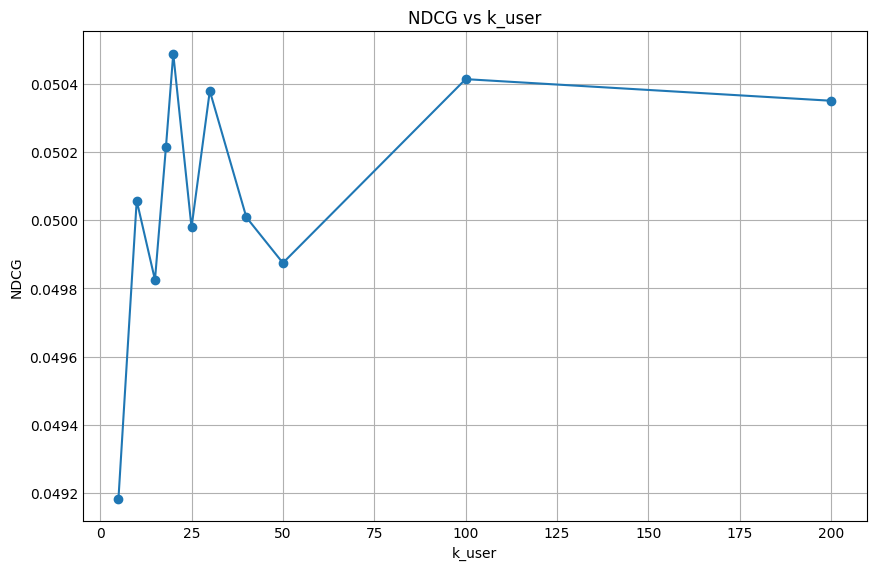

In [15]:
import pandas as pd

df = pd.DataFrame(mean_ndcg_k_item, index=[i for i in range(1, len(mean_dcg_k_item) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.style.use("_mpl-gallery")

plt.figure(figsize=(8, 5))
plt.plot([5,10,15,18,20,25,30,40,50,100,200], df["NDCG"], marker='o')
plt.xlabel("k_user")
plt.ylabel("NDCG")
plt.title("NDCG vs k_user")
plt.grid(True)
plt.show()

### Skenario 4 : Mencari $\Gamma$ terbaik

In [16]:
from Skenario import EksperimenHCF
import DistanceBased.similarities as S

param = {
            "gamma" : [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
            "k_user" : [5],
            "k_item" : [18],
            "alpha_1" : [0.1],
            "alpha_2" : [0],
        }

skenario_kedua = EksperimenHCF("data/ml-100k",object=S.TI,k_user=param["k_user"],k_item=param["k_item"],gamma=param["gamma"],alpha_1=param["alpha_1"],alpha_2=param["alpha_2"],path_file="Eksperimen/tversky_index/FBO_Gamma.joblib",N=20,n=20)

In [17]:
import numpy as np

n = 20
idcg = np.array([sum(np.array([sum(1/np.log2(np.arange(2,n+2))) for n in range(1,n+1)])) for i in range(1,n+1)])
gamma = [round(i*0.1,2) for i in range(11)]


mean_dcg_gamma_fold = []
mean_ndcg_gamma_fold = []
mean_dcg_gamma = []
mean_ndcg_gamma = []

for gamma_index in gamma :
    skenario_kedua_gamma = skenario_kedua.result_skenario[gamma_index][5][18][0.1][0]
    mean_dcg_per_fold = []
    mean_ndcg_per_fold = []

    for i in range(len(skenario_kedua_gamma)) :
        mean_dcg_per_fold += [sum(skenario_kedua_gamma[i])/len(skenario_kedua_gamma[i])]
        mean_ndcg_per_fold += [sum(np.array(skenario_kedua_gamma[i])/idcg[n-1])/len(skenario_kedua_gamma[i])]
    
    mean_dcg_per_fold += [sum(mean_dcg_per_fold)/len(skenario_kedua_gamma)]
    mean_ndcg_per_fold += [sum(mean_ndcg_per_fold)/len(skenario_kedua_gamma)]

    mean_dcg_gamma_fold += [mean_dcg_per_fold]
    mean_ndcg_gamma_fold += [mean_ndcg_per_fold]
    mean_dcg_gamma += [[gamma_index,30,sum(mean_dcg_per_fold)/len(skenario_kedua_gamma)]]
    mean_ndcg_gamma += [[gamma_index,30,sum(mean_ndcg_per_fold)/len(skenario_kedua_gamma)]]

In [18]:
import pandas as pd

gamma = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(mean_dcg_gamma_fold,index=[ f"A1_{str(0.1)}_A2_{str(0)}_K_USER_{str(5)}_K_ITEM_{str(18)}_gamma_{str(i)}" for i in gamma],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
A1_0.1_A2_0_K_USER_5_K_ITEM_18_gamma_0.0,3.772921,1.711829,1.214152,1.021151,1.082240,1.760459
A1_0.1_A2_0_K_USER_5_K_ITEM_18_gamma_0.1,4.086107,1.831561,1.426952,1.356497,1.174369,1.975097
A1_0.1_A2_0_K_USER_5_K_ITEM_18_gamma_0.2,4.766898,2.030986,1.712035,1.786275,1.262958,2.311830
A1_0.1_A2_0_K_USER_5_K_ITEM_18_gamma_0.3,5.216408,2.268499,2.152606,2.128600,1.460249,2.645272
A1_0.1_A2_0_K_USER_5_K_ITEM_18_gamma_0.4,5.840961,2.506082,2.540624,2.484416,1.451636,2.964744
A1_0.1_A2_0_K_USER_5_K_ITEM_18_gamma_0.5,6.138102,2.641569,2.940793,2.796483,1.818511,3.267091
A1_0.1_A2_0_K_USER_5_K_ITEM_18_gamma_0.6,6.271144,2.948970,3.352840,2.951834,2.179974,3.540952
A1_0.1_A2_0_K_USER_5_K_ITEM_18_gamma_0.7,6.079989,3.297579,3.692861,3.120375,2.554758,3.749113
A1_0.1_A2_0_K_USER_5_K_ITEM_18_gamma_0.8,6.048750,3.699188,4.096809,3.224255,2.876114,3.989023
A1_0.1_A2_0_K_USER_5_K_ITEM_18_gamma_0.9,6.038802,3.636033,4.228814,3.336211,3.247893,4.097551


In [19]:
import pandas as pd

gamma = [round(i*0.1,2) for i in range(11)]

pd.DataFrame(mean_ndcg_gamma_fold,index=[ f"A1_{str(0.1)}_A2_{str(0)}_K_USER_{str(5)}_K_ITEM_{str(18)}_GAMMA_{str(i)}" for i in gamma],columns=[f"fold-{i}" if i != 6 else "rata-rata" for i in range(1,7)])

,fold-1,fold-2,fold-3,fold-4,fold-5,rata-rata
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.0,0.042111,0.019106,0.013552,0.011397,0.012079,0.019649
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.1,0.045606,0.020443,0.015927,0.015140,0.013107,0.022045
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.2,0.053205,0.022668,0.019109,0.019937,0.014096,0.025803
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.3,0.058222,0.025319,0.024026,0.023758,0.016298,0.029525
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.4,0.065193,0.027971,0.028357,0.027729,0.016202,0.033090
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.5,0.068509,0.029483,0.032823,0.031212,0.020297,0.036465
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.6,0.069994,0.032914,0.037422,0.032946,0.024331,0.039522
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.7,0.067861,0.036805,0.041217,0.034827,0.028514,0.041845
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.8,0.067512,0.041288,0.045726,0.035987,0.032101,0.044523
A1_0.1_A2_0_K_USER_5_K_ITEM_18_GAMMA_0.9,0.067401,0.040583,0.047199,0.037236,0.036251,0.045734


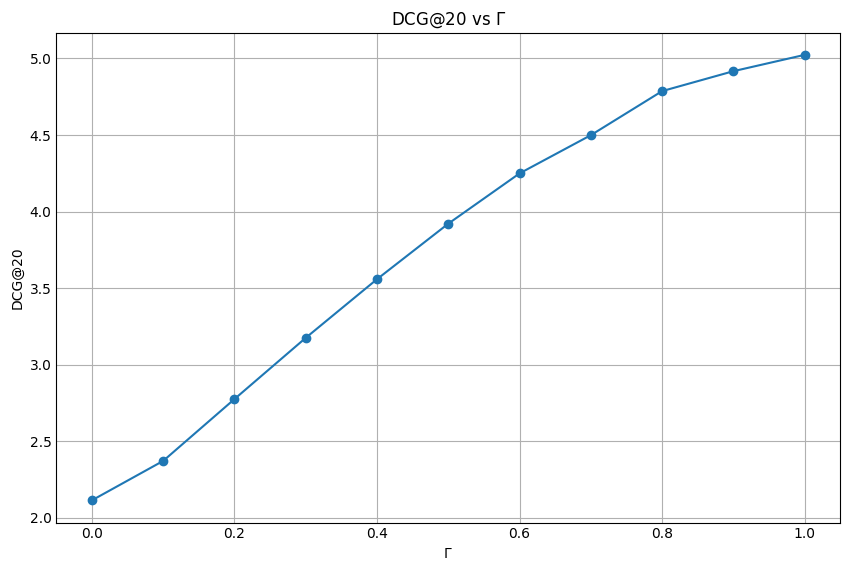

In [20]:
import pandas as pd

df = pd.DataFrame(mean_dcg_gamma, index=[i for i in range(1, len(mean_dcg_gamma) + 1)], columns=["k_user", "k_item", "DCG"])

import matplotlib.pyplot as plt

plt.style.use("_mpl-gallery")

plt.figure(figsize=(8, 5))
plt.plot([round(i*0.1,2) for i in range(11)], df["DCG"], marker='o')
plt.xlabel("$\Gamma$")
plt.ylabel("DCG@20")
plt.title("DCG@20 vs $\Gamma$")
plt.grid(True)
plt.show()

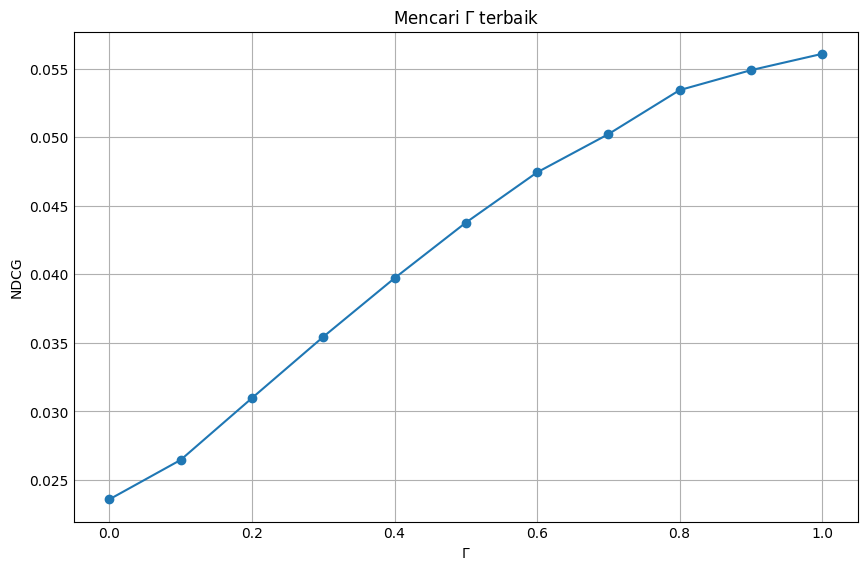

In [21]:
import pandas as pd

df = pd.DataFrame(mean_ndcg_gamma, index=[i for i in range(1, len(mean_ndcg_gamma) + 1)], columns=["k_user", "k_item", "NDCG"])

import matplotlib.pyplot as plt

plt.style.use("_mpl-gallery")

plt.figure(figsize=(8, 5))
plt.plot([round(i*0.1,2) for i in range(11)], df["NDCG"], marker='o')
plt.xlabel("$\Gamma$")
plt.ylabel("NDCG")
plt.title("Mencari $\Gamma$ terbaik")
plt.grid(True)
plt.show()